In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Path to dataset files: /kaggle/input/vegetable-image-dataset


In [ ]:
import tensorflow as tf

gpu_available = tf.config.list_physical_devices('GPU')

if gpu_available:
    print(f"GPU found: {gpu_available}")
    print("TensorFlow is using GPU.")
else:
    print("No GPU found. TensorFlow is using CPU.")


GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow is using GPU.


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Path to the dataset
dataset_path = '/kaggle/input/vegetable-image-dataset'

# Define paths for training, testing, and validation sets
train_dir = os.path.join(dataset_path, 'Vegetable Images', 'train')
validation_dir = os.path.join(dataset_path, 'Vegetable Images', 'validation')

# Image dimensions and batch parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 20 # Number of epochs can be adjusted as needed

# Data augmentation for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data augmentation for validation set (only rescale)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Number of output classes (number of vegetable types)
NUM_CLASSES = len(train_generator.class_indices)
print(f"Number of classes: {NUM_CLASSES}")

# Build AlexNet model
model = Sequential([
    Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Conv2D(256, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=(2, 2)),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Summarize model architecture
model.summary()

print("Starting model training...")
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Training completed.")


Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Number of classes: 15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │        61,455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,813,967 (178.58 MB)

 Trainable params: 46,811,215 (178.57 MB)

 Non-trainable params: 2,752 (10.75 KB)

Starting model training...
Epoch 1/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 216s 443ms/step - accuracy: 0.3664 - loss: 3.4174 - val_accuracy: 0.2409 - val_loss: 3.2215
Epoch 2/20
  1/468 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.5312 - loss: 1.8004

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5312 - loss: 1.8004 - val_accuracy: 0.2409 - val_loss: 3.1499
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 201s 429ms/step - accuracy: 0.5087 - loss: 1.6422 - val_accuracy: 0.1791 - val_loss: 4.5640
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4688 - loss: 1.8779 - val_accuracy: 0.1784 - val_loss: 4.5094
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 200s 427ms/step - accuracy: 0.5963 - loss: 1.3671 - val_accuracy: 0.5218 - val_loss: 1.9626
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5625 - loss: 1.0469 - val_accuracy: 0.5585 - val_loss: 1.8507
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 197s 421ms/step - accuracy: 0.6569 - loss: 1.1870 - val_accuracy: 0.6828 - val_loss: 1.0233
Epoch 8/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7500 - loss: 0.8039 - val_accuracy: 0.7319 - val_loss: 0.8309
Epoch 9/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 195s 416ms/step - accuracy: 0.7225 - loss: 0.9404 - val_acc

In [ ]:
print("### Final training results ###")

# Final training accuracy
final_train_accuracy = history.history['accuracy'][-1]
print(f"Training accuracy: {final_train_accuracy:.4f}")

# Final validation accuracy
final_val_accuracy = history.history['val_accuracy'][-1]
print(f"Validation accuracy: {final_val_accuracy:.4f}")

# Final training loss
final_train_loss = history.history['loss'][-1]
print(f"Training loss: {final_train_loss:.4f}")

# Final validation loss
final_val_loss = history.history['val_loss'][-1]
print(f"Validation loss: {final_val_loss:.4f}")


### Final training results ###
Training accuracy: 0.9375
Validation accuracy: 0.8888
Training loss: 0.4160
Validation loss: 0.4438


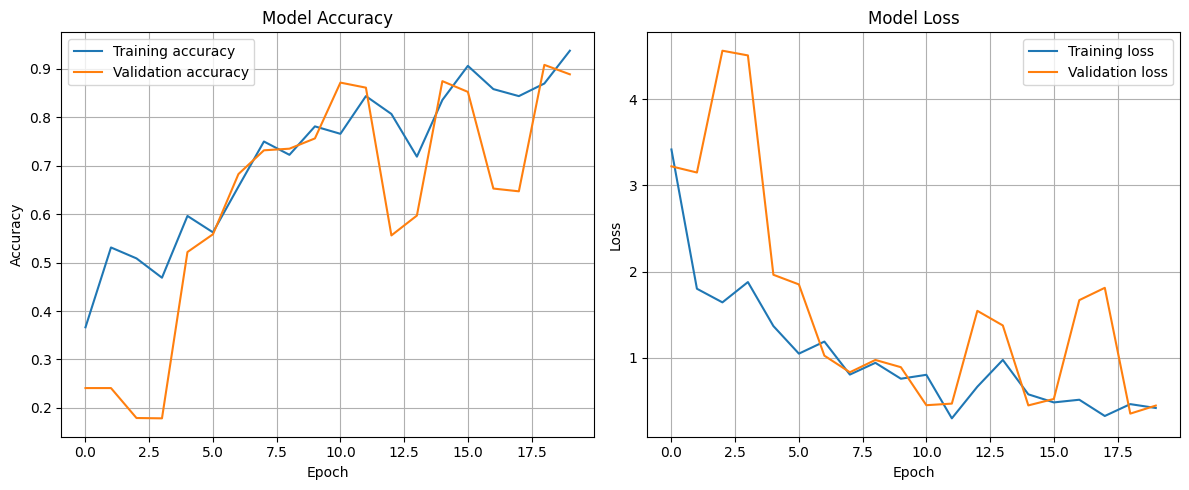

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
